In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

from collections import Counter
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB




In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Capstone Project Kevin Pratama I/youtube_chat_jogja_clean.csv'
data = pd.read_csv(file_path)
data.head(50)

,datetime,author_name,message,cleaned_message,label
0,2024-10-07 08:32:03,KUSUMA,assalamu'alaikum..,assalamualaikum,0
1,2024-10-07 08:58:42,Tata PaNda,wa'alaikumussalam,waalaikumussalam,0
2,2024-10-07 09:20:29,Nimas putri Paranata,udah lewat 22 menit ni,udah lewat 22 menit ni,0
3,2024-10-07 09:30:23,proboyuwono djogdja,16:30 wib,1630 wib,0
4,2024-10-07 09:34:59,Vian Noorcha Putra,Tribun Tv Mana Ini Kenapa Acaranya Belum Dimul...,tribun tv mana ini kenapa acaranya belum dimul...,0
5,2024-10-07 09:37:04,Vian Noorcha Putra,Saya Nonton Apa Ini Tribun Tv Kenapa Acara Way...,saya nonton apa ini tribun tv kenapa acara way...,0
6,2024-10-07 09:47:46,Heri Agus,kapan mulainya min? pengen keburu nonton,kapan mulainya min pengen keburu nonton,0
7,2024-10-07 10:04:01,Deden Abd,assalamu'alaikum,assalamualaikum,0
8,2024-10-07 10:04:51,W,lama,lama,0
9,2024-10-07 10:06:28,Iann_febri,ini nanti bakal live disini taa?,ini nanti bakal live disini taa,0


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6350 entries, 0 to 6349
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   datetime         6350 non-null   object
 1   author_name      6350 non-null   object
 2   message          6348 non-null   object
 3   cleaned_message  6348 non-null   object
 4   label            6350 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 248.2+ KB


In [ ]:
data.describe(include='all')

,datetime,author_name,message,cleaned_message,label
count,6350,6350,6348,6348,6350.000000
unique,3291,4145,2728,2627,NaN
top,2024-10-07 12:34:29,Johnnie Boyles,KETIK DI GOOGLE:WISDOMTOTO,freebet 100rb wisdomtoto,NaN
freq,26,99,931,943,NaN
mean,NaN,NaN,NaN,NaN,0.501890
std,NaN,NaN,NaN,NaN,0.500036
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,1.000000
75%,NaN,NaN,NaN,NaN,1.000000


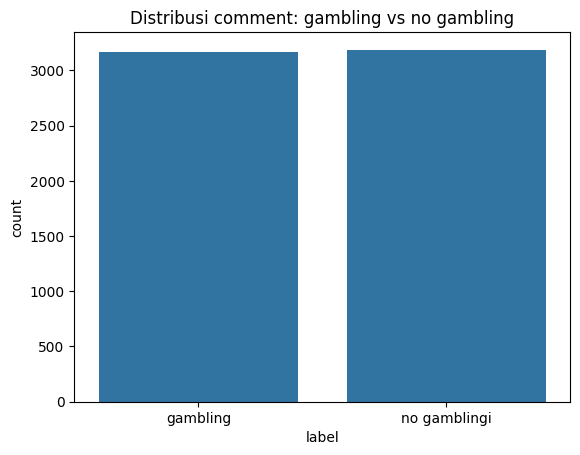

In [ ]:
sns.countplot(x='label', data=data)
plt.title('Distribusi comment: gambling vs no gambling')
plt.xticks([0, 1], ['gambling', 'no gamblingi'])
plt.show()

In [ ]:
data['label'].value_counts(normalize=True)


,proportion
label,
1,0.50189
0,0.49811


In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (data.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))

Missing Values : 
datetime           0
author_name        0
message            2
cleaned_message    2
label              0
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
nan_rows = data[data.isna().any(axis=1)]

nan_rows.head(20)

,datetime,author_name,message,cleaned_message,label
677,2024-10-07 11:55:13,PunthukWetan_Girimerto38,NaN,NaN,0
1133,2024-10-07 12:15:56,Ayu ri97,NaN,NaN,0


In [ ]:

data = data.dropna().reset_index(drop=True)
nan_rows = data[data.isna().any(axis=1)]

nan_rows.head(20)

,datetime,author_name,message,cleaned_message,label


In [ ]:

def get_top_words(texts, n=20):
    all_words = ' '.join(texts).lower()
    words = re.findall(r'\b\w+\b', all_words)
    return Counter(words).most_common(n)


top_judi = get_top_words(data[data['label'] == 1]['cleaned_message'])
top_normal = get_top_words(data[data['label'] == 0]['cleaned_message'])

print("Top gambling promotion:", top_judi)
print("Top nongambling:", top_normal)


Top gambling promotion: [('wisdomtoto', 1990), ('100rb', 1500), ('di', 1285), ('ketik', 1155), ('freebet', 944), ('googlewisdomtoto', 931), ('gratis', 573), ('gacor', 260), ('slot', 244), ('google', 223), ('100', 200), ('pas4d', 112), ('d3p0', 99), ('jd', 99), ('2jt', 99), ('buruan', 99), ('gas', 99), ('garansi', 99), ('meteorwin', 99), ('pasti', 52)]
Top nongambling: [('di', 417), ('jogja', 385), ('bayar', 243), ('angka', 240), ('terbalik', 240), ('istimewa', 153), ('nonton', 140), ('aku', 135), ('kota', 133), ('selamat', 130), ('tahun', 109), ('ulang', 99), ('ini', 84), ('ya', 82), ('slot', 81), ('yg', 78), ('e', 76), ('dari', 70), ('yogyakarta', 68), ('sugeng', 68)]


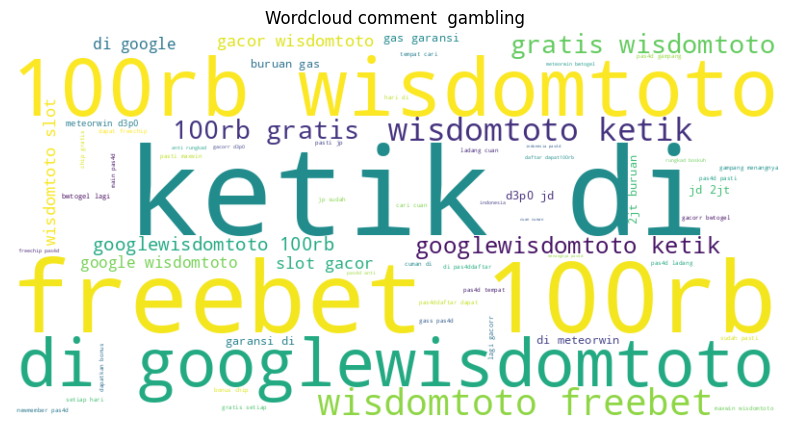

In [ ]:
from wordcloud import WordCloud

judi_text = " ".join(data[data['label'] == 1]['cleaned_message'])
wc = WordCloud(width=800, height=400, background_color='white').generate(judi_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud comment  gambling')
plt.show()


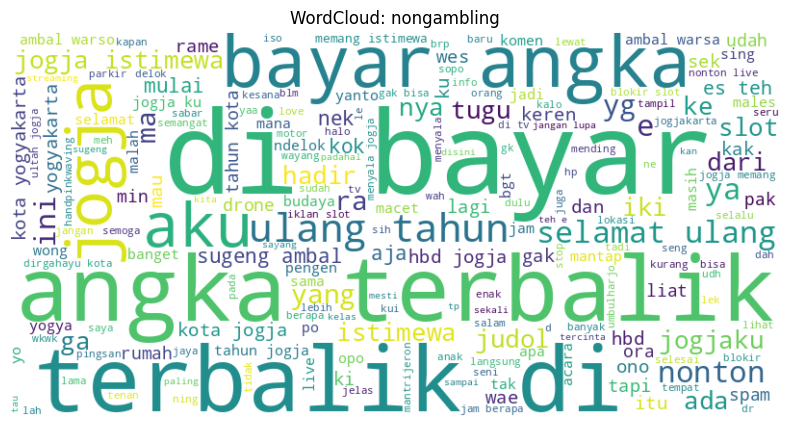

In [ ]:

normal_text = " ".join(data[data['label'] == 0]['cleaned_message'])
wc_normal = WordCloud(width=800, height=400, background_color='white').generate(normal_text)


plt.figure(figsize=(10, 5))
plt.imshow(wc_normal, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: nongambling')
plt.show()


In [ ]:
promosi_judi = data[data['label'] == 1]
promosi_judi
promosi_judi.head(10)


,datetime,author_name,message,cleaned_message,label
102,2024-10-07 10:51:46,Eko Nugroho,VIP 500 RIBU,vip 500 ribu,1
349,2024-10-07 11:18:44,Ikbal Dap,info link gacor,info link gacor,1
1357,2024-10-07 12:24:43,Sinister Six,NewMember :star:PAS4D Pasti Jp SUDAH PASTI,newmember pas4d pasti jp sudah pasti,1
1358,2024-10-07 12:24:43,cosmo,Main PAS4D :star: Gampang Menangnya,main pas4d gampang menangnya,1
1359,2024-10-07 12:24:43,Krishna Amplifier Bhopalgarh,cuman di :smiling_face_with_heart_eyes:PAS4D:s...,cuman di pas4ddaftar dapat freechip,1
1360,2024-10-07 12:24:43,REBAZ 003,:star:PAS4D Tempat Cari Cuan No 1 Indonesia,pas4d tempat cari cuan no 1 indonesia,1
1361,2024-10-07 12:24:43,jatt life,Dapatkan Bonus Chip Gratis Setiap Hari di PAS4D!,dapatkan bonus chip gratis setiap hari di pas4d,1
1362,2024-10-07 12:24:43,@Indiaफूडी,PAS4D :star: Gacor,pas4d gacor,1
1363,2024-10-07 12:24:43,new movies 2023,PAS4D :star: Gacor,pas4d gacor,1
1364,2024-10-07 12:24:43,Krishnaz shorts king 1.0,Main PAS4D :star: Gampang Menangnya,main pas4d gampang menangnya,1


In [ ]:

X = data['cleaned_message']
y = data['label']

# CountVectorizer (Bag of Words)
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)


model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

print("Features used:", vectorizer.get_feature_names_out())

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       633
           1       0.91      1.00      0.95       637

    accuracy                           0.95      1270
   macro avg       0.95      0.95      0.95      1270
weighted avg       0.95      0.95      0.95      1270

Features used: ['08' '10' '100' ... 'zzzzzzzzzzz' 'zzzzzzzzzzzzz' 'zzzzzzzzzzzzzzz']


In [ ]:

y_pred = model.predict(X_test)


accuracy = classification_report(y_test, y_pred)
print(accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

incorrect_indexes = y_pred != y_test
incorrectly_classified = data.iloc[incorrect_indexes.index[incorrect_indexes]]




              precision    recall  f1-score   support

           0       1.00      0.90      0.95       633
           1       0.91      1.00      0.95       637

    accuracy                           0.95      1270
   macro avg       0.95      0.95      0.95      1270
weighted avg       0.95      0.95      0.95      1270

[[571  62]
 [  2 635]]


In [ ]:
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Training Accuracy: 0.9958645135880267
Test Accuracy: 0.9496062992125984


In [ ]:
print("\n data with wrong classification:")
incorrectly_classified[['datetime', 'author_name', 'message', 'label']].head(50)


 data with wrong classification:


,datetime,author_name,message,label
1513,2024-10-07 12:26:37,Thaqy Rantaugraphy,zzzzzz,0
1220,2024-10-07 12:19:27,TRISIYANA SIWANDITA,owalah,0
3534,2024-10-07 13:14:48,ANIMASIONYO,KASIAN.. PENONTONYA..,0
996,2024-10-07 12:09:19,Viko NAEP,mase tremor:rolling_on_the_floor_laughing:,0
5927,2024-10-07 14:05:58,yuwana yuwana,mantaaap,0
1188,2024-10-07 12:18:12,Novi Kurniawati,endeng enet,0
2446,2024-10-07 12:40:31,lli plo,situs slot,0
706,2024-10-07 11:56:07,mikhailaluvenaagrisya,:face-red-heart-shape::face-red-heart-shape::f...,0
296,2024-10-07 11:12:06,Eko Budi,hdr,0
1672,2024-10-07 12:30:27,Indri Tri,anjir razman ... pers konpres,0


# prepare prediction to inject to granite

In [ ]:

X_test_df = pd.DataFrame(X_test.toarray(), columns=vectorizer.get_feature_names_out(), index=y_test.index)


X_test_df['prediction'] = y_pred


test_results = X_test_df.merge(data[['author_name', 'cleaned_message']], left_index=True, right_index=True)


print("\nHasil Prediksi:")
print(test_results[['author_name', 'cleaned_message', 'prediction']].head(10))



Hasil Prediksi:
             author_name                                    cleaned_message  \
730          Rangga Bima  selamat ultah jogja mugi2 umr e ditambah karo ...   
2131            jdm cars                          ketik di googlewisdomtoto   
3070       SANJAY SANJAY                            100rb gratis wisdomtoto   
6101  Most comedy video                            freebet 100rb wisdomtoto   
217         Jonx Channel  sama om aja dek sini pipietpersonturqouisewavi...   
3545                  oi                                            jogjaku   
5768     Social Media Jo                          ketik di googlewisdomtoto   
3674     Aditya Muhammad  sopir drone lagi nganggo chip turboo dikirane ...   
6174          Kleyber0_o                            angka terbalik di bayar   
4614          Sah Kareem                           freebet 100rb wisdomtoto   

      prediction  
730            0  
2131           1  
3070           1  
6101           1  
217            0  

In [ ]:
test_results[['author_name', 'cleaned_message', 'prediction']].head(20)

,author_name,cleaned_message,prediction
730,Rangga Bima,selamat ultah jogja mugi2 umr e ditambah karo ...,0
2131,jdm cars,ketik di googlewisdomtoto,1
3070,SANJAY SANJAY,100rb gratis wisdomtoto,1
6101,Most comedy video,freebet 100rb wisdomtoto,1
217,Jonx Channel,sama om aja dek sini pipietpersonturqouisewavi...,0
3545,oi,jogjaku,0
5768,Social Media Jo,ketik di googlewisdomtoto,1
3674,Aditya Muhammad,sopir drone lagi nganggo chip turboo dikirane ...,0
6174,Kleyber0_o,angka terbalik di bayar,0
4614,Sah Kareem,freebet 100rb wisdomtoto,1


In [ ]:

sample_gambling = test_results[test_results['prediction'] == 1].sample(n=min(100, sum(test_results['prediction'] == 1)), random_state=42)
sample_nogambling = test_results[test_results['prediction'] == 0].sample(n=min(100, sum(test_results['prediction'] == 0)), random_state=42)


#Granite Prompt

In [ ]:

def comment_format(df):
    return "\n".join([
        f"{row['author_name']}: {row['cleaned_message']}"
        for _, row in df.iterrows()
    ])

sample_gambling = comment_format(sample_gambling)
sample_nogambling = comment_format(sample_nogambling)


In [ ]:
sample_gambling

"AstrooSpace: ketik di googlewisdomtoto\nMansi: dapatkan bonus chip gratis setiap hari di pas4d\nOnline Earning ways : 100rb gratis wisdomtoto\nभगवन BAKHTI: ketik di googlewisdomtoto\nFree fire lover boy: ketik di googlewisdomtoto\nadnanakram49: ketik di googlewisdomtoto\n4321__ FF: slot gacor wisdomtoto\nLyrics Boulevard: ketik di googlewisdomtoto\nSiam Gamer: freebet 100rb wisdomtoto\nuk69 Gjnc: pas4d anti rungkad boskuh\nPurna Kunwar: 100rb gratis wisdomtoto\nmr unknown: ketik di googlewisdomtoto\nHARSH KUMAR: slot gacor wisdomtoto\nNovi Kurniawati: endeng enet\nChampionCircuitTV: 100rb gratis wisdomtoto\nyoyoyoyoyo: ketik di google wisdomtoto\nJitendra Yadav: ketik di googlewisdomtoto\nManish Sahu 47 : freebet 100rb wisdomtoto\nJlo22: freebet 100rb wisdomtoto\nPd: 100rb gratis wisdomtoto\nali Hazara: freebet 100rb wisdomtoto\nAakash_ff: ketik di googlewisdomtoto\nPUBG Wala: ketik di googlewisdomtoto\nItz_bike lovers👀: freebet 100rb wisdomtoto\nQe: slot gacor wisdomtoto\nlikhari_pb_

In [ ]:
sample_nogambling

'Kenzie irona: bagus banget\nEfi Puji: aku goleki live e mau malah nemune israel\nmaster of pubg: angka terbalik di bayar\nKurniawan Fauzi: aki nonton di depan sendiri\nMovie Explainer : angka terbalik di bayar\nThe Ayaan Vlogs: angka terbalik di bayar\nAdenaa: heh menenggg\nReno : bangka belitung hadir\nVida Permata: videonya lebih clear di youtubenya dinas pariwisata\nadadehhh: aku bakol\nDimari Sahaja: sopir drone e kebelet sajak efacebluesmiling\nHelma Wati: sugeng ambal warsa jogja\nBerkah mulia: facebluesmilingfacebluesmilingfacebluesmiling\nPutri Lestari: jogja selalu kuerennn kota yang dikangenin banyak orang\n26_ Nur Aini: info parkir yg dekat\njaka triwiyana: 268 tahun jogja tambah istimewa\nDwi Haryani: wow\nedelweiss enda: byk spam\nAdenaa: sholat duluu\nSakha raja: cepet pak lama banget\nFF legend: angka terbalik di bayar\nLintang : hut kotaq yg istimewa\nWiji Priyanto: no miras\nIndri Tri: eteh ya kk aquaaaa\nS: hut jogja semoga tetap membumiiii\nVall(´ω`): belohhh mah sl

In [ ]:
!pip install langchain_community
!pip install replicate

In [ ]:
from langchain_community.llms import Replicate
import os
from google.colab import userdata
# Set the API token
api_token = userdata.get('api_token')
os.environ["REPLICATE_API_TOKEN"] = api_token
# Model setup
model = "ibm-granite/granite-3.3-8b-instruct"
output = Replicate(
model=model,
replicate_api_token=api_token,
)

#### IMPORTANT ####
Because the output of this Granite are limited, i seperated the prompt to 5 and only analyze online gambling. We dont need to analyze nongambling comments.

In [ ]:
prompt1 = f"""
You are a digital linguistics expert and cybersecurity analyst tasked with identifying language patterns and disguise strategies in online gambling promotional comments.
Our team has collected comment samples from a YouTuber's livestream titled: LIVE Wayang Jogja Night Carnival #9, 268th Anniversary Celebration of Yogyakarta City.
We have built an XGBoost model and will send you the classification results in the format (Username: Comment).
Below are the classified online gambling promotional comments:
{sample_gambling}

Below are the classified non-promotional (regular) comments:
{sample_nogambling}

Please perform a deep analysis and provide insights systematically. Use linguistic, social, and semantic approaches to answer:

1. **Differences in language style:**
   - Explain the characteristics of the promotional comment language style.
   - Use examples of phrases that frequently appear.
   - Do promotional comments use language of persuasion, urgency, links, or specific symbols?

Provide answers that are:
- Direct and to the point, no need for introductory sentences.
- Concise and factual.
- Contain direct examples from the data.
- Summarized, focusing on key points without lengthy explanations.
"""


In [ ]:
prompt2 = f"""
You are a digital linguistics expert and cybersecurity analyst tasked with identifying language patterns and disguise strategies in online gambling promotional comments.
Our team has collected comment samples from a YouTuber's livestream titled: LIVE Wayang Jogja Night Carnival #9, 268th Anniversary Celebration of Yogyakarta City.
We have built an XGBoost model and will send you the classification results in the format (Username: Comment).
Below are the classified online gambling promotional comments:
{sample_gambling}

Below are the classified non-promotional (regular) comments:
{sample_nogambling}

Please perform a deep analysis and provide insights systematically. Use linguistic, social, and semantic approaches to answer:

1. **User account patterns (author_name):**
   - Are there any strange, repetitive, bot-like, or unnatural account name patterns in the promotional comments? Provide 5 examples.

Provide answers that are:
- Direct and to the point, no need for introductory sentences.
- Concise and factual.
- Contain direct examples from the data.
- Summarized, focusing on key points without lengthy explanations.
"""


In [ ]:
prompt3 = f"""
You are a digital linguistics expert and cybersecurity analyst tasked with identifying language patterns and disguise strategies in online gambling promotional comments.
Our team has collected comment samples from a YouTuber's livestream titled: LIVE Wayang Jogja Night Carnival #9, 268th Anniversary Celebration of Yogyakarta City.
We have built an XGBoost model and will send you the classification results in the format (Username: Comment).
Below are the classified online gambling promotional comments:
{sample_gambling}

Below are the classified non-promotional (regular) comments:
{sample_nogambling}

Please perform a deep analysis and provide insights systematically. Use linguistic, social, and semantic approaches to answer:

1. **Disguise or spam strategies:**
   - Are there indications of using spaces, unique symbols, or broken words to evade detection by moderation systems?
   - Provide 5 concrete examples and analyze their meaning.

Provide answers that are:
- Direct and to the point, no need for introductory sentences.
- Concise and factual.
- Contain direct examples from the data.
- Summarized, focusing on key points without lengthy explanations.
"""


In [ ]:
prompt4 = f"""
You are a digital linguistics expert and cybersecurity analyst tasked with identifying language patterns and disguise strategies in online gambling promotional comments.
Our team has collected comment samples from a YouTuber's livestream titled: LIVE Wayang Jogja Night Carnival #9, 268th Anniversary Celebration of Yogyakarta City.
We have built an XGBoost model and will send you the classification results in the format (Username: Comment).
Below are the classified online gambling promotional comments:
{sample_gambling}

Below are the classified non-promotional (regular) comments:
{sample_nogambling}

Please perform a deep analysis and provide insights systematically. Use linguistic, social, and semantic approaches to answer:

1. **Dominant theme or narrative in promotional comments:**
   - What is the common call-to-action used? (e.g., get rich quick, bonuses, login, links, etc.)

Provide answers that are:
- Direct and to the point, no need for introductory sentences.
- Concise and factual.
- Contain direct examples from the data.
- Summarized, focusing on key points without lengthy explanations.
"""


In [ ]:
prompt5 = f"""
You are a digital linguistics expert and cybersecurity analyst tasked with identifying language patterns and disguise strategies in online gambling promotional comments.
Our team has collected comment samples from a YouTuber's livestream titled: LIVE Wayang Jogja Night Carnival #9, 268th Anniversary Celebration of Yogyakarta City.
We have built an XGBoost model and will send you the classification results in the format (Username: Comment).
Below are the classified online gambling promotional comments:
{sample_gambling}

Below are the classified non-promotional (regular) comments:
{sample_nogambling}

Please perform a deep analysis and provide insights systematically. Use linguistic, social, and semantic approaches to answer:

1. **Potential false positives:**
   - Are there any non-promotional comments that might have been misclassified?
   - What are the characteristics of these comments, and how can they be distinguished from genuine promotions?

Provide answers that are:
- Direct and to the point, no need for introductory sentences.
- Concise and factual.
- Contain direct examples from the data.
- Summarized, focusing on key points without lengthy explanations.
"""


In [ ]:
parameters = {
    "top_k": 10,
    "top_p": 0.9,
    "max_tokens": 2000,
    "min_tokens": 50,
    "random_seed": None,
    "repetition_penalty": 1.5,
    "stopping_criteria": "length",
    "stopping_sequence": " "
}

In [ ]:
from IPython.display import Markdown, display

In [ ]:
response1 = output(prompt1, parameters=parameters)
# response = output.invoke(prompt_final)
# # Print the response
# print("Granite Model Response:\n")
# print(response)

display(Markdown(response1))

### Deep Analysis of Promotional vs. Regular Comments

#### 1. Differences in Language Style:

**Promotional Comment Language Style Characteristics:**

- **Direct Commands/Instructions:** Frequent use of imperative sentences instructing users to "ketik di googlewisdomtoto" (type on Google WisdomToto).
- **Repetitive Phrases:** "100rb gratis wisdomtoto" (100rb free on WisdomToto) is repeated across multiple usernames, indicating a standardized promotional script.
- **Focus on Incentives:** Phrases like "bonus chip gratis" (free bonus chips), "freebet 100rb" (100rb free bet), and "slot gacor" (winning slot) highlight enticing offers.
- **Use of Symbols and Emoticons:** Occasional use of symbols (e.g., "💰") or emoticons (e.g., 😀) to grab attention.
- **Brand/Platform Mentions:** Specific mentions of platforms like "pas4d" and "wisdomtoto," indicating targeted advertising.

**Examples:**

- "ketik di googlewisdomtoto" (type on Google WisdomToto) - Direct command.
- "dapatkan bonus chip gratis setiap hari di pas4d" (get free bonus chips every day at pas4d) - Promise of daily rewards.
- "100rb gratis wisdomtoto" - Repeated incentive.
- "slot gacor wisdomtoto" - Direct promotion of a specific game.

**Linguistic Persuasion and Urgency:**

- **Persuasion:** Phrases like "gratis" (free) and "bonus" (bonus) are used to persuade users by appealing to their desire for free rewards.
- **Urgency:** Implicit urgency through repetitive daily offers ("setiap hari" - every day), encouraging immediate action.

#### 2. Social and Semantic Insights:

- **Target Audience:** The variety of usernames (e.g., gaming enthusiasts, music lovers) suggests an attempt to broaden

In [ ]:

response2 = output(prompt2, parameters=parameters)
# response = output.invoke(prompt_final)
# # Print the response
# print("Granite Model Response:\n")
# print(response)

display(Markdown(response2))



1. **User account patterns (author_name):**

- **Repetitive phrases**: "ketik di googlewisdomtoto" appears 19 times, indicating a coordinated promotional strategy.
- **Numerical patterns**: Several usernames include numbers ("4321__ FF", "Rd_69blade", "Johnnie Boyles: d3p0 100 jd 2jt buruan gas garansi 100% di meteorwin"), possibly suggesting bot or script-generated accounts.
- **Language diversity**: The presence of usernames in different languages (e.g., "भगवन BAKHTI" in Hindi, "ABCD 🏏 cricketer", "Nguyễn Minh Nhật (Gin)") might be an attempt to broaden the reach, possibly using multilingual bots or human accounts mimicking non-native speakers.
- **Generic or nonsensical names**: Accounts like "facepinktears", "fishorangewideeyes", "glassespurpleyellowdiamondhandpinkwavinghandpinkwavinghandpinkwavinghandpinkwavinghandpinkwavinghandpinkwavinghandpinkwavinghandpinkwavingtextgreengameover" are unusual and possibly bots or accounts created to avoid detection.
- **Common gaming/tech terms**: Incorporating terms like "PUBG", "Free Fire", "slot gacor" into usernames ("PUBG Wala", "Itz_bike lovers👀") aims to attract specific gaming or tech-savvy demographics.

These patterns suggest a mix of manual and automated strategies to promote gambling sites, leveraging language diversity and common interests to appear more organic. The repetitive and numerical patterns, however, point towards potential bot activity or coordinated human efforts.

In [ ]:

response3 = output(prompt3, parameters=parameters)
# response = output.invoke(prompt_final)
# # Print the response
# print("Granite Model Response:\n")
# print(response)

display(Markdown(response3))



### Disguise or Spam Strategies:

1. **Broken Words & Symbols:**
   - **Example:** "pas4d anti rungkad boskuh" by uk69 Gjnc.
   - **Analysis:** The phrase "anti rungkad" could be an attempt to bypass filters by inserting a common Indonesian term ('antirungkad' means 'anti-fraud') alongside the gambling site 'pas4d'.

2. **Misspellings & Code-like Text:**
   - **Example:** "d3p0 100 jd 2jt buruan gas garansi 100% di meteorwin" by Johnnie Boyles.
   - **Analysis:** The use of numbers and abbreviations (d3p0, jd, 2jt) mimics a coded language, possibly to avoid simple keyword detection systems.

3. **Foreign Language Insertion:**
   - **Example:** "भगवन BAKHTI: ketik di googlewisdomtoto" by भगवन BAKHTI.
   - **Analysis:** Including Hindi text ("भगवन BAKHTI") amidst an otherwise English comment could be a tactic to confuse automated filters trained primarily on English.

4. **Emoticon & Special Character Overuse:**
   - **Example:** "facebluesmilingfacebluesmilingfacebluesmiling" by Berkah mulia.
   - **Analysis:** Excessive use of emoticons and special characters could be an attempt to dilute the comment with non-textual elements, making it harder for keyword-based filters to detect gambling promotions.

5. **Generic & Repetitive Phrases:**
   - **Example:** "ketik di googlewisdomtoto" by multiple users (AstrooSpace, Mansi, Online Earning ways, etc.).
   - **Analysis:** Repetition of a simple, seemingly innocuous phrase could be a tactic to appear as benign user engagement while subtly promoting the site.

### Non-Promotional Comment Analysis:

1. **Relevance to Livestream Content:**
   - Many comments discuss aspects related to the livestream (Wayang Jogja Night Carn

In [ ]:

response4 = output(prompt4, parameters=parameters)
# response = output.invoke(prompt_final)
# # Print the response
# print("Granite Model Response:\n")
# print(response)

display(Markdown(response4))



1. **Dominant theme or narrative in promotional comments:**

- **Common Call-to-Action:** The primary call-to-action in these promotional comments is the instruction to "ketik di googlewisdomtoto" (type in Google Wisdomtoto), which suggests users to search for the platform to access free chips, bonuses, or gaming opportunities. Other frequent mentions include "freebet 100rb wisdomtoto" (100rb free bet on Wisdomtoto), "100rb gratis wisdomtoto" (100rb free on Wisdomtoto), and specific game references like "slot gacor wisdomtoto" (fast/hot slot game on Wisdomtoto).

- **Key Phrases:** "bonus chip gratis" (free bonus chips), "gratis wisdomtoto" (free on Wisdomtoto), "freebet" (free bet), "slot gacor" (fast/hot slot), indicating a focus on enticing users with free credits, bonuses, and slot games.

- **Language Patterns:** The comments utilize repetitive, imperative language ("ketik", "dapatkan", "100rb gratis") to create a sense of urgency and simplicity, targeting a broad audience including non-native English speakers (e.g., "भगवन BAKHTI", "ADH EDITZ" in non-English scripts).

- **Disguise Strategies:** Comments often avoid explicit gambling mentions, instead using euphemisms like "chips" and "free bets," which may bypass content filters while still conveying the intended message to those familiar with gambling jargon.

- **Social Dynamics:** The use of usernames and repeated phrases across different accounts suggests coordinated efforts or bot activities, possibly to amplify reach and legitimize the promotion through perceived social proof (multiple users endorsing the same action).

- **Semantic Analysis:** The terms "wisdomtoto" and "pas4d" are central, indicating specific online gambling platforms. The consistent association of these names with enticing offers implies an attempt to drive traffic to these sites under the guise of free rewards.

In [ ]:

response5 = output(prompt5, parameters=parameters)
# response = output.invoke(prompt_final)
# # Print the response
# print("Granite Model Response:\n")
# print(response)

display(Markdown(response5))



### Deep Analysis of Classified Comments

#### Potential False Positives

1. **Non-promotional Comments Misclassified as Promotions:**

   - **Examples:**
     - "Kenzie irona: bagus banget" (Kenzie irona: very good)
     - "Efi Puji: aku goleki live e mau malah nemune israel" (Efi Puji: I'm so tired, live streaming, almost in Israel)
     - "Movie Explainer : angka terbalik di bayar" (Movie Explainer: odd numbers paid)
     - "The Ayaan Vlogs: angka terbalik di bayar" (The Ayaan Vlogs: odd numbers paid)
     - "Adenaa: heh menenggg" (Adenaa: hehe)
     - "Reno : bangka belitung hadir" (Reno: Belitung island is here)
     - "Vida Permata: videonya lebih clear di youtubenya dinas pariwisata" (Vida Permata: video is clearer on my YouTube, Dinas Pariwisata)
     - "adadehhh: aku bakol" (adadehhh: I'm bored)
     - "Dimari Sahaja: sopir drone e kebelet sajak efacebluesmiling" (Dimari Sahaja: drone driver to Beleteng, face with blushing smiley)
     - "Helma Wati: sugeng ambal warsa jogja" (Helma Wati: Sugeng, Warsaw, Jogja)
     - "Berkah mulia: facebluesmilingfacebluesmilingfacebluesmiling" (Berkah mulia: face with blue smiling repeatedly)
     - "Putri Lestari: jogja selalu kuerennn kota yang dikangenin banyak orang" (Putri Lestari: Jogja is always desired, a much-desired city)
     - "26_ Nur Aini: info parkir yg dekat" (26_ Nur Aini: information on nearby parking)
     - "j

In [ ]:
# Notice how the output seems incomplete, that is because of limited granite prompt output